In [63]:
import os, sys, pickle
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EI_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'eigen-interactions'))
sys.path.insert(0, EI_DIR)
from eigen_steering import EigenMap, PROMOTER_SEQ, RAND_BARCODE
from fast_logo import fast_logo

SEAM_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
FG_DIR = os.path.join(SEAM_ROOT, 'results', 'foregrounds')

with open(os.path.join(SEAM_ROOT, 'libraries', 'hippo_target_library.pkl'), 'rb') as f:
    lib = pickle.load(f)
df = lib['df']

# Build seq -> npz index lookup (npz used dropna(sequence) only)
JOINT_CSV = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/Cell_line_MoCon/Cross-line_analysis/pred_first/joint_data/joint_library_combined.csv'
joint_df = pd.read_csv(JOINT_CSV).dropna(subset=['sequence']).reset_index(drop=True)
seq_to_npz = {s: i for i, s in enumerate(joint_df['sequence'])}

# Load npz once
attr_data = np.load(lib['attr_npz_path'], allow_pickle=False)

In [64]:
# --- Select sequence ---
# condition: 'same-diff', 'diff-diff', 'same-same'
# rank: 0 = most negative EI_1, 1 = 2nd, etc.
CONDITION_FILTER = 'same-diff'
RANK = 0  # (n+1)th most negative within this condition

subset = df[df['condition'] == CONDITION_FILTER].sort_values('EI_1 var x r').reset_index(drop=True)
print(f"{len(subset)} seqs in '{CONDITION_FILTER}'")
print(subset[['seq_idx', 'EI_1 var x r', 'pred_K562', 'pred_HepG2']].head(10))

row = subset.iloc[RANK]
SEQ_IDX = row['seq_idx']
CONDITION = row['condition']
SEQ = row['sequence']

print(f"\nSelected: seq_idx={SEQ_IDX}, EI_1={row['EI_1 var x r']:.4f}")
print(f"  pred_K562={row['pred_K562']:.3f}, pred_HepG2={row['pred_HepG2']:.3f}")
print(f"  K562_log2FC={row['K562_log2FC']:.3f}, HepG2_log2FC={row['HepG2_log2FC']:.3f}")

353 seqs in 'same-diff'
   seq_idx  EI_1 var x r  pred_K562  pred_HepG2
0    56772     -0.784848  -0.982792    1.836308
1    38571     -0.784601  -0.711974    0.926399
2    53717     -0.753810  -0.418904    1.016396
3    56720     -0.739573  -0.795999    1.861329
4    55788     -0.735543  -0.488176    0.286052
5    49334     -0.728182  -0.592026    0.690473
6    56910     -0.724025  -0.766621    2.011120
7    46756     -0.723678  -0.958071    0.847493
8    42132     -0.723614  -0.575259    1.334094
9    56731     -0.722818  -0.727875    1.150200

Selected: seq_idx=56772, EI_1=-0.7848
  pred_K562=-0.983, pred_HepG2=1.836
  K562_log2FC=-1.208, HepG2_log2FC=1.852


In [65]:
# --- TFMoDISco / annotation params ---
WINDOW_SIZE = 10
FLANK = 5
PVAL_THRESH = 0.05
N_NEAREST = 5
TOP_K = 1
MAX_PARALOGS = 1

In [66]:
# Load cached attributions + annotate motifs + rank by binding score
import importlib, eigen_steering; importlib.reload(eigen_steering)
from eigen_steering import EigenMap

npz_idx = seq_to_npz[SEQ]
ei1 = row['EI_1 var x r']
raw_name = row['name']
if '|' in raw_name:
    locus = raw_name.split('|')[0]
    n_motifs = raw_name.count(';') + 1
    seq_name = f'{locus} ({n_motifs} motifs)'
else:
    seq_name = raw_name

em = EigenMap(cell_types=['HepG2', 'K562'])
em.load_sequences([SEQ])
ohe = em.X.numpy()
for ct in ['HepG2', 'K562']:
    hyp = attr_data[f'attr_{ct}'][npz_idx:npz_idx+1]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = attr_data[f'predictions_{ct}'][npz_idx:npz_idx+1]

em.load_expression()
em.annotate_motifs(window_size=WINDOW_SIZE, flank=FLANK, pval_thresh=PVAL_THRESH, n_nearest=N_NEAREST)
em.eigendecompose()
em.annotate_tf_binding(method='gaussian')

hits_source = em.motif_hits_ranked
actuals = {'HepG2': row['HepG2_log2FC'], 'K562': row['K562_log2FC']}

def title(ct, label):
    return f'{ct} {label} | {seq_name} | pred={em.predictions[ct][0]:.3f} | actual={actuals[ct]:.3f} | EI_1={ei1:.3f}'

# One-hot for masking SEAM outputs to WT base
ohe_enh = np.zeros((230, 4), dtype=np.float32)
for i, b in enumerate(SEQ):
    ohe_enh[i, 'ACGT'.index(b)] = 1.0

print(f"{seq_name} (seq {SEQ_IDX}) | EI_1={ei1:.3f} | {len(hits_source['HepG2'][0])} HepG2 hits, {len(hits_source['K562'][0])} K562 hits")

EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_twostep_v4_do03', 'K562': 'K562_twostep_v4_do03'}
Loaded 1 sequences, X shape: torch.Size([1, 4, 281])
  HepG2: 58721 genes, median TPM=0.00
  K562: 58721 genes, median TPM=0.00
  TF lookup: 57133 gene symbols across ['HepG2', 'K562']
  HepG2: 3 motif hits (p<0.05)
  K562: 5 motif hits (p<0.05)
Eigendecomposed 1 sequences (enhancer only, 230bp)
annotate_tf_binding(gaussian): 8/8 TF assignments changed across 1 sequences (sigma=0.642)
C:SLEA_hg18:chr2:210861483-210861650 (8 motifs) (seq 56772) | EI_1=-0.785 | 3 HepG2 hits, 5 K562 hits


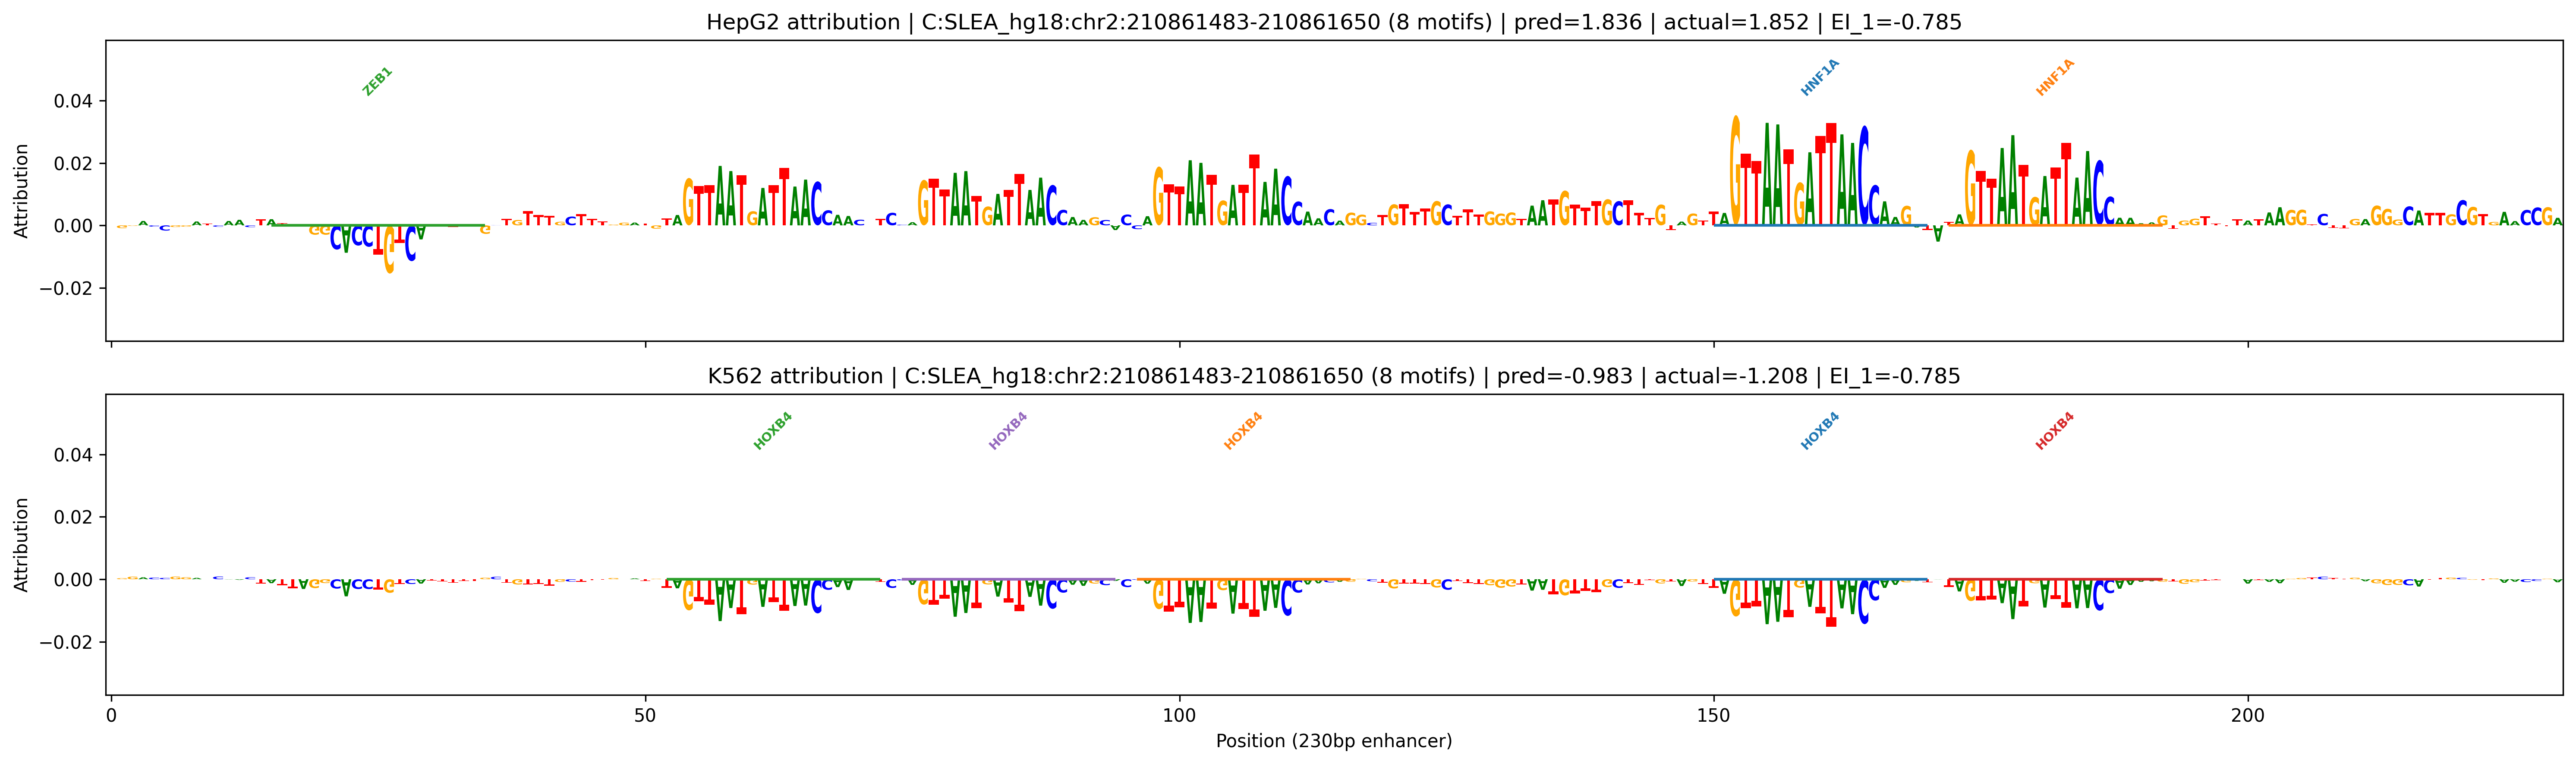

In [67]:
# Normal attribution maps
MOTIF_COLORS = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 1, figsize=(20, 6), sharex=True, dpi=300)
all_vals = np.concatenate([em.attr[ct][0].ravel() for ct in ['HepG2', 'K562']])
yabs = max(abs(all_vals.min()), abs(all_vals.max())) * 1.05

for ci, ct in enumerate(['HepG2', 'K562']):
    fast_logo(em.attr[ct][0, :, :230].T, ax=axes[ci], ylim=(-yabs, yabs))
    axes[ci].set_title(title(ct, 'attribution'))
    axes[ci].set_ylabel('Attribution')

    hits = hits_source[ct][0]
    if hits:
        ylim = axes[ci].get_ylim()
        yrange = ylim[1] - ylim[0]
        axes[ci].set_ylim(ylim[0], ylim[1] + yrange * 0.3)
        for hi, h in enumerate(hits):
            color = MOTIF_COLORS[hi % len(MOTIF_COLORS)]
            axes[ci].plot([h['start'], h['end']], [0, 0], lw=1.5, color=color, solid_capstyle='butt')
            mid = (h['start'] + h['end']) / 2
            axes[ci].annotate(h['tf'], xy=(mid, ylim[1] + yrange * 0.05),
                              fontsize=7, ha='center', va='bottom', rotation=45, color=color, fontweight='bold')

axes[-1].set_xlabel('Position (230bp enhancer)')
plt.tight_layout()
plt.show()

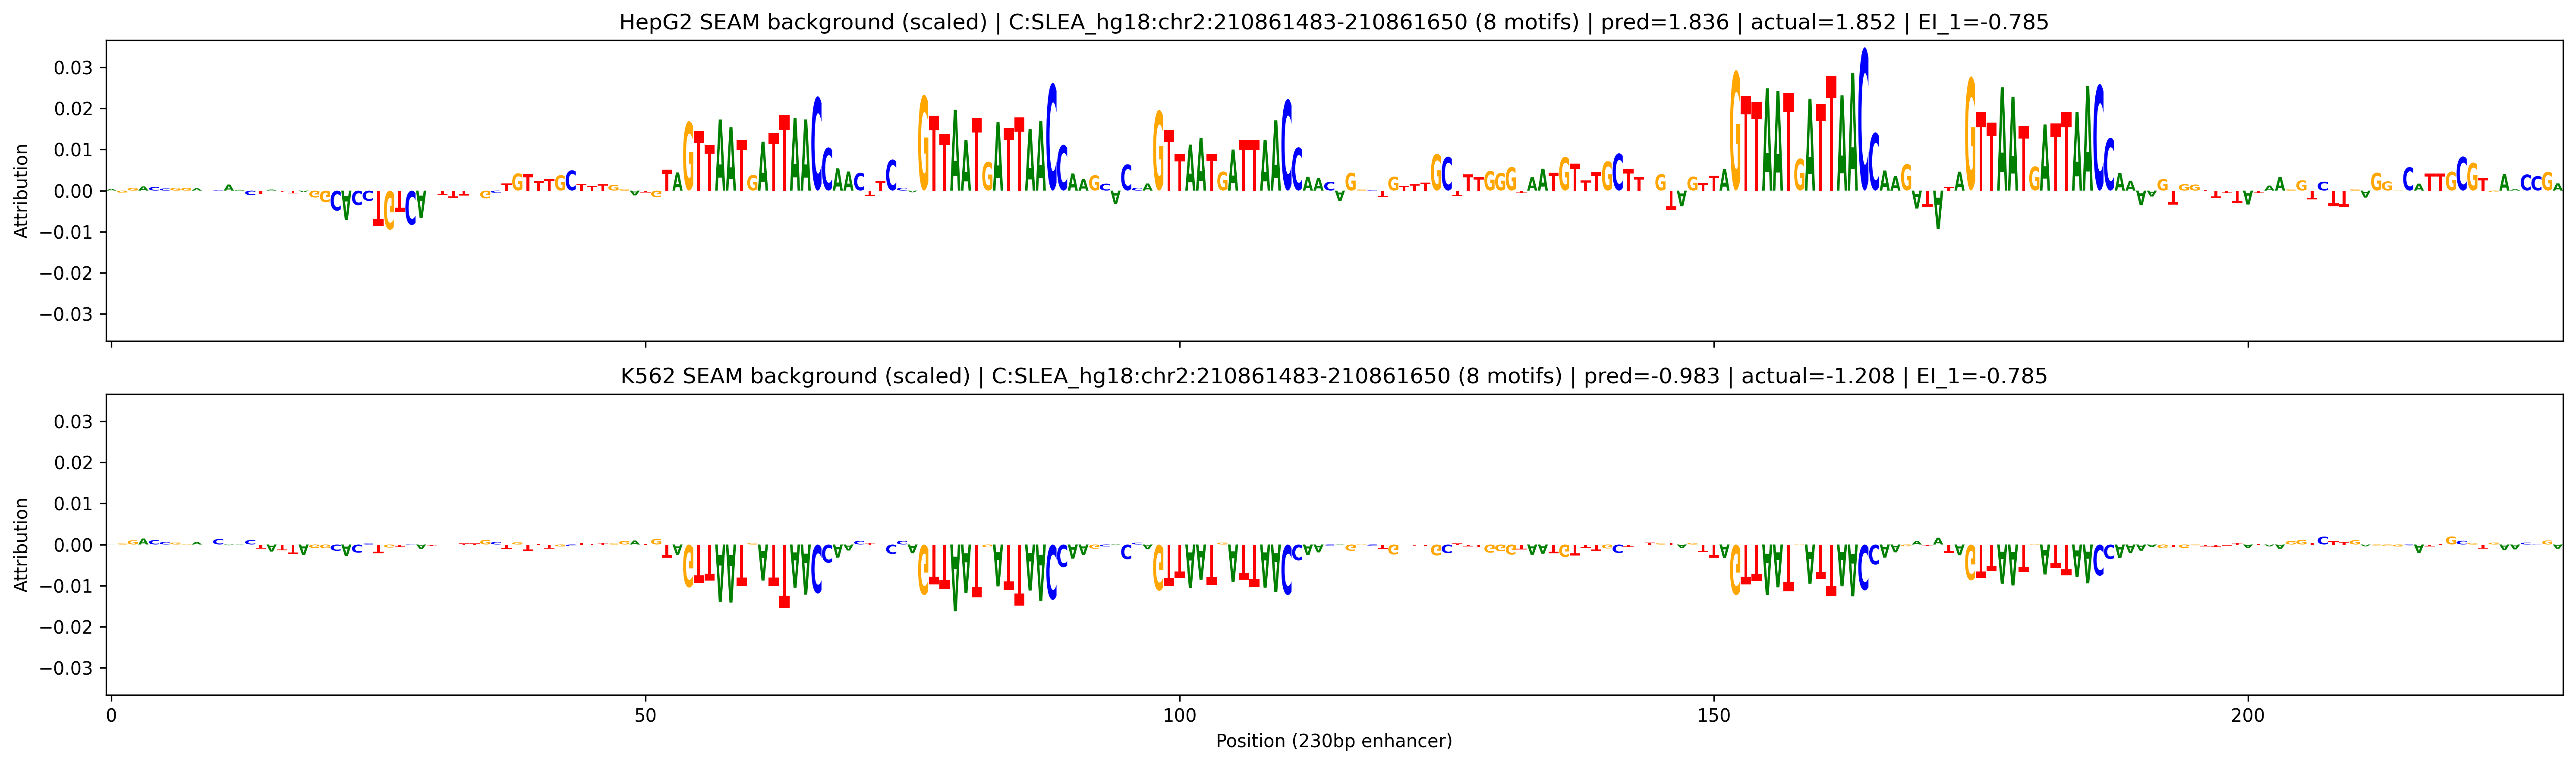

In [68]:
# SEAM scaled backgrounds
bgs = {ct: np.load(os.path.join(FG_DIR, ct, str(SEQ_IDX), 'average_background_scaled.npy')) * ohe_enh
       for ct in ['HepG2', 'K562']}
yabs_bg = max(abs(v).max() for v in bgs.values()) * 1.05

fig, axes = plt.subplots(2, 1, figsize=(20, 6), sharex=True, dpi=300)
for ci, ct in enumerate(['HepG2', 'K562']):
    fast_logo(bgs[ct], ax=axes[ci], ylim=(-yabs_bg, yabs_bg))
    axes[ci].set_title(title(ct, 'SEAM background (scaled)'))
    axes[ci].set_ylabel('Attribution')

axes[-1].set_xlabel('Position (230bp enhancer)')
plt.tight_layout()
plt.show()

EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_twostep_v4_do03', 'K562': 'K562_twostep_v4_do03'}
Loaded 1 sequences, X shape: torch.Size([1, 4, 281])
  HepG2: 58721 genes, median TPM=0.00
  K562: 58721 genes, median TPM=0.00
  TF lookup: 57133 gene symbols across ['HepG2', 'K562']
  HepG2: 5 motif hits (p<0.05)
  K562: 5 motif hits (p<0.05)
Eigendecomposed 1 sequences (enhancer only, 230bp)
annotate_tf_binding(gaussian): 10/10 TF assignments changed across 1 sequences (sigma=0.642)
Foreground hits: 5 HepG2, 5 K562


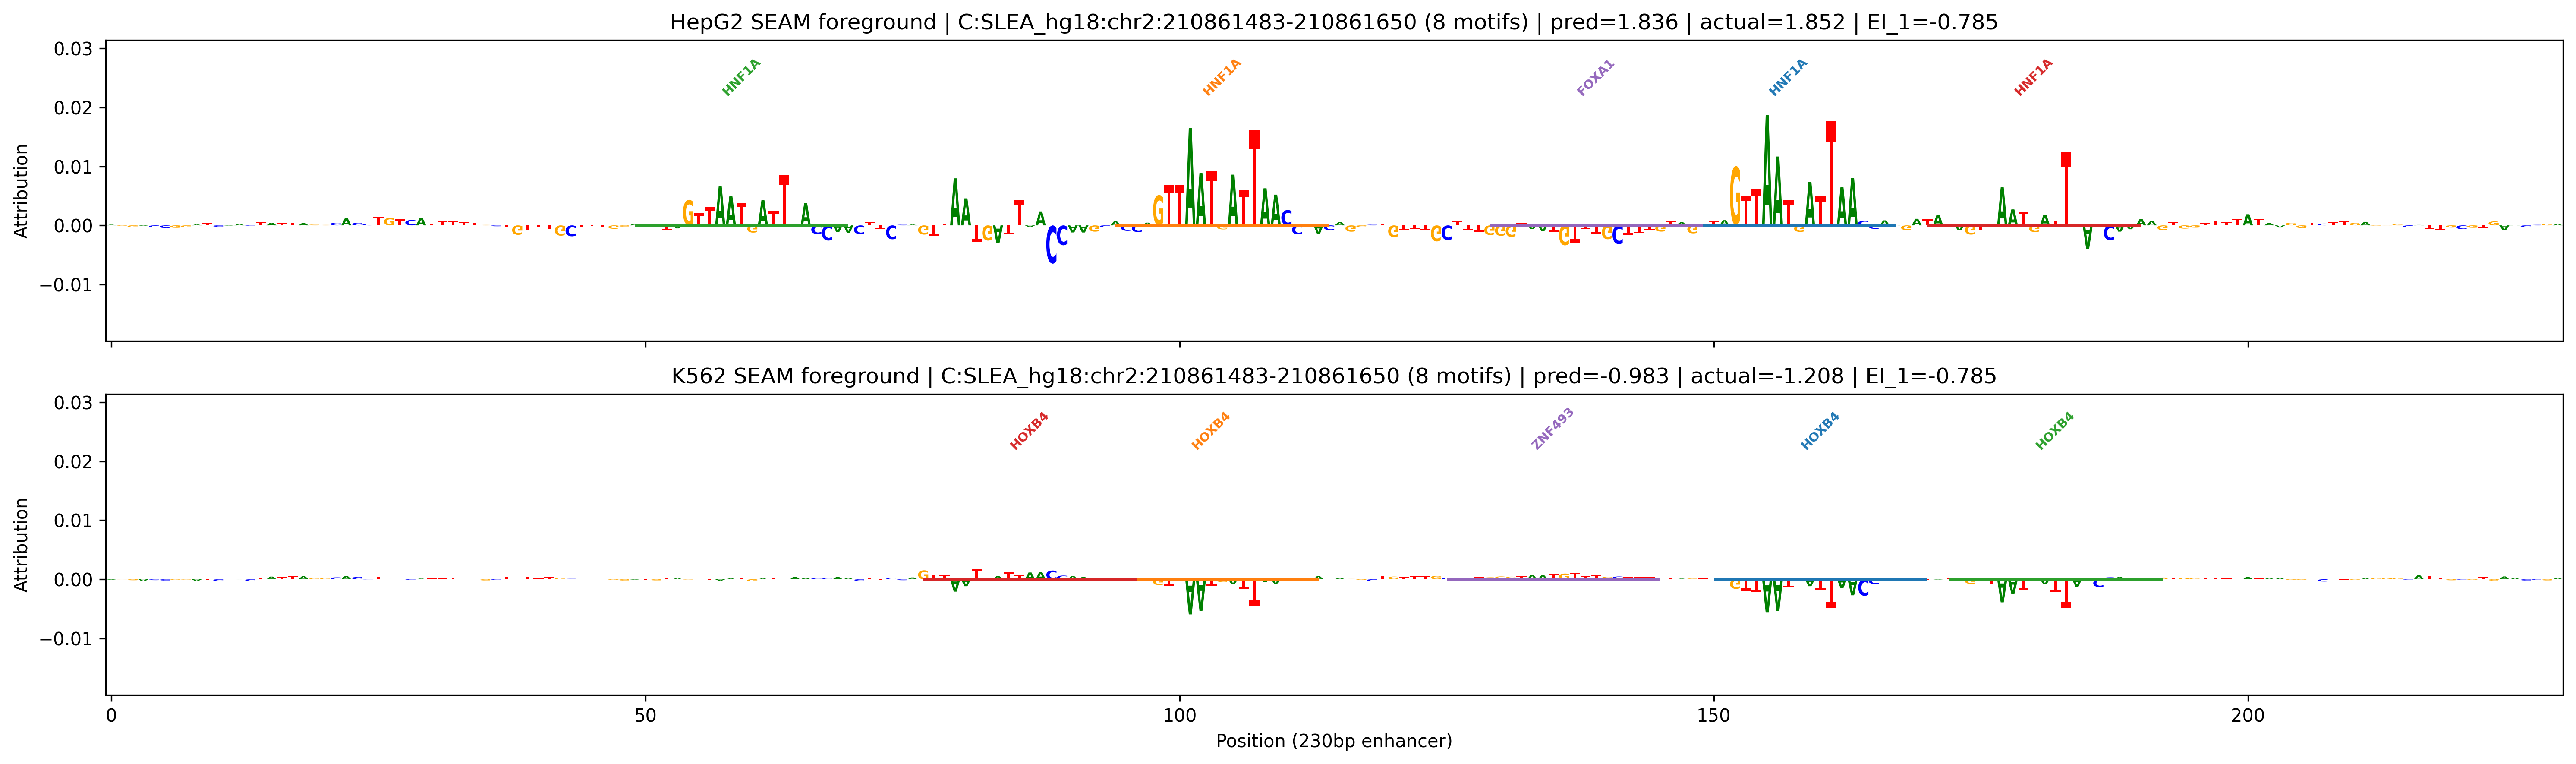

In [69]:
# Annotate motifs on SEAM foregrounds (same hyperparams as raw attributions)
em_fg = EigenMap(cell_types=['HepG2', 'K562'])
em_fg.load_sequences([SEQ])
ohe_fg = em_fg.X.numpy()

for ct in ['HepG2', 'K562']:
    fg_nlc = np.load(os.path.join(FG_DIR, ct, str(SEQ_IDX), 'foreground_scaled.npy'))  # (230, 4)
    fg_cf = fg_nlc.T[np.newaxis]  # (1, 4, 230)
    fg_281 = np.zeros((1, 4, 281), dtype=np.float32)
    fg_281[:, :, :230] = fg_cf
    em_fg.attr_hyp[ct] = fg_281
    em_fg.attr[ct] = fg_281 * ohe_fg
    em_fg.importance[ct] = em_fg.attr[ct].sum(axis=1)
    em_fg.predictions[ct] = em.predictions[ct]

em_fg.load_expression()
em_fg.annotate_motifs(window_size=WINDOW_SIZE, flank=FLANK, pval_thresh=PVAL_THRESH, n_nearest=N_NEAREST)
em_fg.eigendecompose()
em_fg.annotate_tf_binding(method='gaussian')

fg_hits_source = em_fg.motif_hits_ranked
print(f"Foreground hits: {len(fg_hits_source['HepG2'][0])} HepG2, {len(fg_hits_source['K562'][0])} K562")

# Plot SEAM foregrounds with foreground-based motif annotations
fgs = {ct: np.load(os.path.join(FG_DIR, ct, str(SEQ_IDX), 'foreground_scaled.npy')) * ohe_enh
       for ct in ['HepG2', 'K562']}
yabs_fg = max(abs(v).max() for v in fgs.values()) * 1.05

fig, axes = plt.subplots(2, 1, figsize=(20, 6), sharex=True, dpi=300)
for ci, ct in enumerate(['HepG2', 'K562']):
    fast_logo(fgs[ct], ax=axes[ci], ylim=(-yabs_fg, yabs_fg))
    axes[ci].set_title(title(ct, 'SEAM foreground'))
    axes[ci].set_ylabel('Attribution')

    hits = fg_hits_source[ct][0]
    if hits:
        ylim = axes[ci].get_ylim()
        yrange = ylim[1] - ylim[0]
        axes[ci].set_ylim(ylim[0], ylim[1] + yrange * 0.3)
        for hi, h in enumerate(hits):
            color = MOTIF_COLORS[hi % len(MOTIF_COLORS)]
            axes[ci].plot([h['start'], h['end']], [0, 0], lw=1.5, color=color, solid_capstyle='butt')
            mid = (h['start'] + h['end']) / 2
            axes[ci].annotate(h['tf'], xy=(mid, ylim[1] + yrange * 0.05),
                              fontsize=7, ha='center', va='bottom', rotation=45, color=color, fontweight='bold')

axes[-1].set_xlabel('Position (230bp enhancer)')
plt.tight_layout()
plt.show()